###**BERN02 Exercise: Resampling methods**

Name: Yang Shann Wen

Date: 29 September 2026

In this exercise, we will look into **resampling methods**, particularly **cross-validation** and **bootstrap method**, which involves fitting the same statistical method multiple times using different subsets of the training data to estimate the variance in predictions or a quantity of interest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from scipy.special import gammaln
from scipy.optimize import minimize

###**Part 1: Cross-Validation**
Cross-validation is used to evaluate the performance of a statistical learning method by estimating the test error, which is to estimate the variance of predictions for a new observation.
$$\hat{V}(\hat{f}(x_0)) = \hat{V}(\hat{y}|x_0)$$

Cross-validation can be done through many methods, including validation set, and K-fold cross validation.

####**1.1 Validation set**
In this section, we will work on the 'air pollution data set' (`pollution_cleaneddata.csv`), and use the validation set method to evaluate the predictive performance of our model by estimating the variance of a prediction $\hat{V}(\hat{f}(x_0))$.

We specify a polynomial regression model with a degree that predicts mortality (y, `MORT`) as a function of the average July temperature in degrees F (x, `JULT`).

$$y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \dots + \beta_p x_i^p + \varepsilon_i$$

<br>

The steps to carry out the validation set method:
1. Split data into a training set and a validation set.
2. Fit the model using the training set.
3. Make predictions for the validation set.
4. Estimate the variance of a prediction as the Mean Square Error (MSE):
$$\hat{V}(\hat{f}(x_0)) = MSE_{\text{test}} = \frac{\sum_{i \in \text{test}} (y_i - \hat{y}_i)^2}{n_{\text{test}}}$$




In [2]:
# Load data
df_pollution = pd.read_csv('/content/pollution_cleaneddata.csv')

In [3]:
# Extract the data from the respective columns
X_data = df_pollution[['JULT']].values
y_data = df_pollution['MORT'].values

In [4]:
# Define a function for the fitting of polynomial regression model
def poly_regression(x, y, degree):
    if hasattr(x, 'values'):
        x = x.values
    if x.ndim == 1:
        x = x.reshape(-1, 1)

    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    poly_model.fit(x, y)
    return poly_model

In [5]:
# Split the data into equal sized training set and testing set (validation set), with random seed 42
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.5, random_state=42)

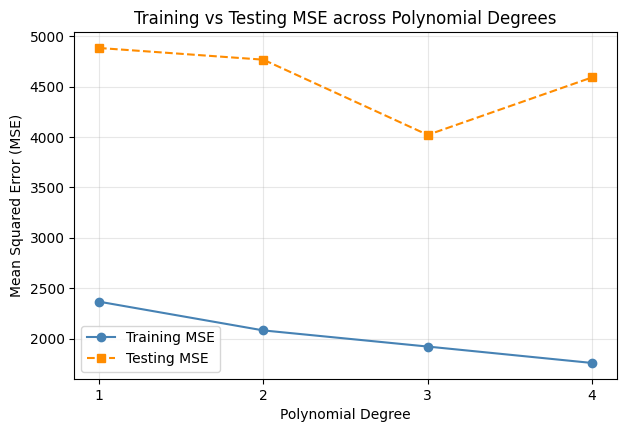

In [6]:
# Calculate the MSE of train set and test set across different polynomial degrees

# Initiate blank lists to store results
train_mse = []
test_mse = []
degree = [1,2,3,4]

# Loop the fitting through all polynomial degree
for d in degree:
    model = poly_regression(X_train, y_train, d)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate MSE
    train_mse.append(np.mean((y_train - y_pred_train) ** 2))
    test_mse.append(np.mean((y_test - y_pred_test) ** 2))

# Plot
plt.figure(figsize=(7, 4.5))
plt.plot(degree, train_mse, 'o-', label='Training MSE', color='steelblue')
plt.plot(degree, test_mse, 's--', label='Testing MSE', color='darkorange')
plt.xticks(degree)
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training vs Testing MSE across Polynomial Degrees')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

From the graph generated above, polynomial degree 3 is recommended because it gives the smallest testing MSE among the four models. This suggests that degree 3 provides the best predictive performance for unseen observations among the models considered.

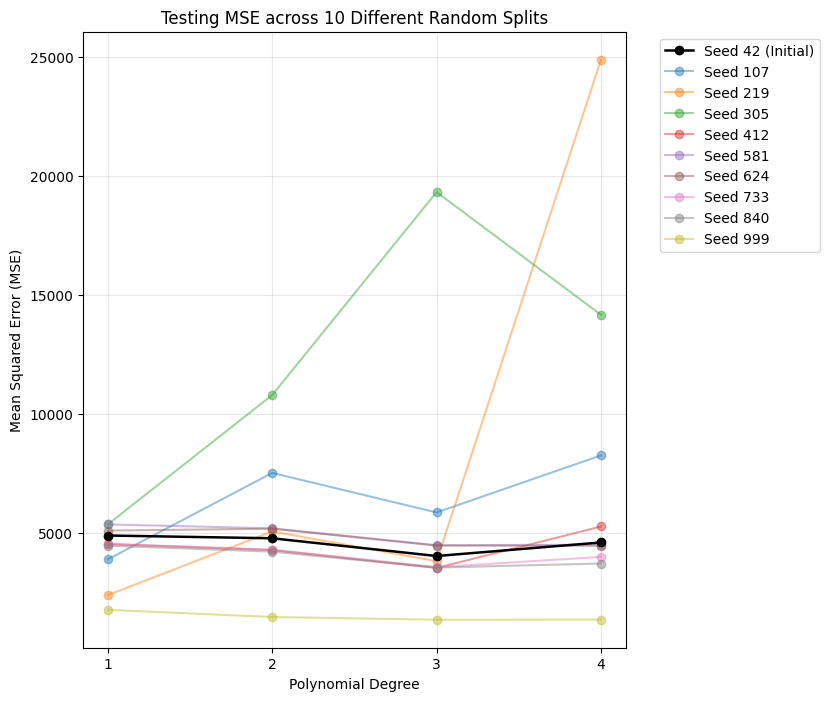

In [7]:
# The validation set procedure is repeated with other random seeds to evaluate whether the seeds affect the results

# Set 10 random seeds
seeds = [42, 107, 219, 305, 412, 581, 624, 733, 840, 999]
degree = [1,2,3,4]

plt.figure(figsize=(7, 8))

# Loop through each seed
for i, s in enumerate(seeds):

  # Split data into training set and testing set
  X_train_seed, X_test_seed, y_train_seed, y_test_seed = train_test_split(X_data, y_data, test_size=0.5, random_state=s)

  seed_test_mse = []

  # Loop the fitting through all polynomial degree and calculate the testing MSE
  for d in degree:
        m = poly_regression(X_train_seed, y_train_seed, degree=d)

        y_pred_test_seed = m.predict(X_test_seed)

        seed_test_mse.append(np.mean((y_test_seed - y_pred_test_seed) ** 2))

  # Black line for random seed 42
  if s == 42:
        plt.plot(degree, seed_test_mse, marker='o', color='black', linewidth=1.8, zorder=5, label='Seed 42 (Initial)')
  else:
        plt.plot(degree, seed_test_mse, marker='o', alpha=0.45, label=f'Seed {s}')

plt.xticks(degree)
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Testing MSE across 10 Different Random Splits')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # moves legend outside so plot stays clean
plt.show()

From the graph generated above, we can see that while many of the seed produce similar results as the initial random seed 42 (eg: seed 733, seed 840), some of the random seed generated very different MSE results compared to the random seed 42 (eg: seed 219, seed 305). Different random splits contain different observations, which can cause the estimated prediction error to vary considerably between splits. This is one limitation of the validation set approach.

####**1.2 K-fold Cross Validation**
In this section, we will look into K-fold cross validation using the same dataset.

The steps to carry out the K-fold approach:
1. Split data into K sets with equal sizes.
2. Let the first set be the validations set.
3. Fit the model to the remaining data.
4. Estimate the variance of a prediction as the Mean Square Error (MSE):
$$MSE_{\text{k}} = \frac{\sum_{i \in \text{set k}} (y_i - \hat{y}_i)^2}{n_{\text{k}}}$$
5. Repeat for all K sets.

The estimation of the variance of a new prediction is estimated from the average of the resulting K estimates of error:
$$\hat{V}(\hat{f}(x_0)) = \frac{\sum_{{k=1}}^K MSE_{k}}{K}$$




In [8]:
# Convert the data into 1-dimensional
x = np.asarray(X_data).ravel()
y = np.asarray(y_data).ravel()

# Set degree and number of folds (K)
degree = 2
K = 3

# Set seed
np.random.seed(42)
n = len(x)
indices = np.random.permutation(n)

# Split indices into K equal chunks
folds = np.array_split(indices, K)

cv_mse = []

# K-fold cross-validation loop
for i in range(K):
    val_set = folds[i]
    train_set = np.setdiff1d(indices, val_set)

    X_train, y_train = x[train_set], y[train_set]
    X_val, y_val = x[val_set], y[val_set]

    # Fit polynomial model
    coeffs = np.polyfit(X_train, y_train, deg=degree)

    # Predict on validation set
    y_pred_val = np.polyval(coeffs, X_val)

    # Calculate MSE
    mse_k = np.mean((y_val - y_pred_val) ** 2)
    cv_mse.append(mse_k)

# Estimate variance of prediction from the average of MSE
estimated_variance = np.sum(cv_mse) / K

print(f"Polynomial Degree: {degree}")
print(f"MSE per fold: {[round(float(m), 2) for m in cv_mse]}")
print(f"Estimated Variance of a New Prediction: {estimated_variance:.2f}")

Polynomial Degree: 2
MSE per fold: [5427.17, 3542.75, 3799.61]
Estimated Variance of a New Prediction: 4256.51


In [9]:
# The K-fold cross validation procedure is repeated with other random seeds to evaluate whether the seeds affect the results

# Set 10 random seeds
seeds = [42, 107, 219, 305, 412, 581, 624, 733, 840, 999]
degree = 2
K = 3

all_variance = []

print(f"Estimated Variance of a New Prediction:")

# Loop through all seeds
for s in seeds:
    np.random.seed(s)

    n = len(x)
    indices = np.random.permutation(n)
    folds = np.array_split(indices, K)

    cv_mse = []

    # K-fold cross-validation loop and calculate MSE
    for i in range(K):
        val_set = folds[i]
        train_set = np.setdiff1d(indices, val_set)

        X_train, y_train = x[train_set], y[train_set]
        X_val, y_val = x[val_set], y[val_set]

        coeffs = np.polyfit(X_train, y_train, deg=degree)
        y_pred_val = np.polyval(coeffs, X_val)

        mse_k = np.mean((y_val - y_pred_val) ** 2)
        cv_mse.append(mse_k)

    estimated_variance = np.sum(cv_mse) / K
    all_variance.append(estimated_variance)

    print(f"Seed {s:3d}: {estimated_variance:.2f}")

Estimated Variance of a New Prediction:
Seed  42: 4256.51
Seed 107: 3728.10
Seed 219: 4990.30
Seed 305: 4409.04
Seed 412: 3609.43
Seed 581: 4786.69
Seed 624: 4103.43
Seed 733: 3819.70
Seed 840: 3457.15
Seed 999: 3544.17


According to the different estimated variance of a new prediction, the results are similar across seeds, especially when compared to the validation set method.

In the validation set approach, changing the random seed causes high variability because only a single subset of the data is evaluated. Under $K$-fold cross-validation, the estimates across all 10 seeds remain within the same consistent scale ($\sim 3500\text{–}5000$). This consistency occurs because every observation is included in the test set exactly once, which averages out the bulk of the random partitioning noise.

However, there is still some variability primarily because $K = 3$ is relatively small. With only 3 folds, each model trains on just $67\%$ of the data, making the fitted coefficients more sensitive to which points are withheld. Besides, averaging over only 3 folds provides less smoothing against high-leverage outliers than standard 5- or 10-fold CV.

###**Part 2: Bootstrap**
Bootstrap is a method used to measure error for a quantity of interest, which could be a parameter (eg: slope, $\beta_1$), or a prediction ($\hat{y}$). The main point of bootstrap is emulating the process of obtaining new sample sets by sampling with replacement from the original dataset.

In this section, we will estimate the standard error of the slope ($\beta_1$) of the line in the Poisson regression of the birds over time from the 'bird count dataset' (`bird_count.csv`). The Poisson regression model fitted with maximum likelihood was carried out in the last assignment.
$$Y_i \sim \mathrm{Poisson}(\lambda_i)$$
$$\log(\lambda_i) = \beta_0 + \beta_1x_i$$

<br>

The steps to carry out the bootstrap approach:
1. Sampling with replacement to create new sample sets (bootstrap sample, $b=1, 2, ..., B$)
2. For each bootstrap sample, fit a model (the Poisson regression model) and derive the quantity of interest (the slope, $\beta_1$ ).
3. The variance for the quantity of interest is estimated by the bootstrap sample variance:
$$\hat{V}(\hat{q})^{*B} = \frac{\sum_{b=1}^{B} (q^{*b} - \bar{q}^{*B})^2}{B - 1}$$

      where $\bar{q}^{*B} = \frac{\sum_{b=1}^{B} q^{*b}}{B}$ is the average of the bootstrap sample.

4. The estimated Standard Error for the quantity of interest is the square root of the bootstrap sample variance:
$$SE^{*B} = \sqrt{\hat{V}(\hat{q})^{*B}}$$

In [10]:
# Load the dataset
df_bird = pd.read_csv('/content/bird_count.csv')

In [11]:
# Run the Poisson regression model from last assignment

# Extract the values from respective columns
x_bird = df_bird['yr']
y_bird = df_bird['count']

x_baseline = 1999
x_diff = x_bird - x_baseline

# Function for negative log likelihood
def negative_log_likelihood(theta, x, y):
  """
  Parameters:
  theta: Parameters of the model (beta_0, beta_1)
  x: The predictor observations (year - 1999)
  y: The response variable observations (bird count)

  Output:
  -log_1: The value of negative log likelihood

  """

  beta_0, beta_1 = theta
  lam = np.exp(beta_0 + beta_1 * x)
  log_factorial_y = gammaln(y + 1)
  log_l = np.sum(-lam + y * np.log(lam) - log_factorial_y)

  return -log_l

# Fit the model
initial_guess = [0.0, 0.0]

result = minimize(
    fun=negative_log_likelihood,
    x0=initial_guess,
    args=(x_diff, y_bird),
    method="BFGS"
)

print("Optimization successful:", result.success)
print("Optimization message:", result.message)

beta_0_hat, beta_1_hat = result.x

print("\nEstimated parameters:")
print(f"beta_0_hat = {beta_0_hat}")
print(f"beta_1_hat = {beta_1_hat}")

Optimization successful: True
Optimization message: Optimization terminated successfully.

Estimated parameters:
beta_0_hat = 2.3253319407283524
beta_1_hat = -0.03244317973781568


In [12]:
# Estimate the standard error using the bootstrap method

x_bird = np.asarray(x_diff)
y_bird = np.asarray(y_bird)
n = len(x_bird)

B = 1000  # Number of bootstrap replicates
np.random.seed(42)

boot_beta_1 = []

for b in range(B):
    # Resample indices with replacement
    boot_idx = np.random.choice(n, size=n, replace=True)
    x_boot = x_bird[boot_idx]
    y_boot = y_bird[boot_idx]

    # Minimize negative log likelihood on resampled data
    # Use my existing beta estimates as the starting guess
    res = minimize(
        fun=negative_log_likelihood,
        x0=[beta_0_hat, beta_1_hat],
        args=(x_boot, y_boot),
        method="BFGS",
    )

    # Save the slope (beta_1) if optimization succeeded
    if res.success:
        boot_beta_1.append(res.x[1])

boot_beta_1 = np.array(boot_beta_1)
B_success = len(boot_beta_1)

# Calculate average of the bootstrap sample
boot_beta_1_avg = np.mean(boot_beta_1)

# Calculate the bootstrap sample variance
boot_beta_1_var = np.sum((boot_beta_1 - boot_beta_1_avg) ** 2) / (B_success - 1)

# Calculate the standard error for the quantity of interest
boot_beta_1_sd = np.sqrt(boot_beta_1_var)

print(f"Original beta_1_hat: {beta_1_hat:.5f}")
print("Successful bootstrap samples:", B_success)
print(f"Bootstrap Variance: {boot_beta_1_var:.5f}")
print(f"Bootstrap Standard Error (SE) of beta_1: {boot_beta_1_sd:.5f}")

Original beta_1_hat: -0.03244
Successful bootstrap samples: 848
Bootstrap Variance: 0.00127
Bootstrap Standard Error (SE) of beta_1: 0.03558


When running $B = 1000$ bootstrap replicates with random seed `42`, our estimated standard error for the slope parameter $\hat{\beta}_1$ is approximately **$0.03558$** (with a bootstrap sample variance of $0.00127$).